In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as ss
from tqdm import tqdm

RESOURCES_ROOT = Path.cwd().parent / 'resources'


## Task family information

- The full task family is a binary yes/no judgment over conjunctions of 4 binary latent dimensions:
  - side: right / left
  - transparency: transparent / opaque
  - glossiness: glossy / matte
  - size: large / small
- The full task catalog is determined by those 4 dimensions and the conjunction arities:
  - 8 one-way tasks
  - 24 two-way conjunctions
  - 32 three-way conjunctions
  - 16 four-way conjunctions
  - 80 tasks total
- `task_id` is the comma-separated list of active factor values in fixed factor order:
  - one-way example: `right`
  - three-way example: `transparent,glossy,right`
- Prompts are generated from the task spec rather than handwritten one by one:
  - side-only example: `Is there an object on the **right**?`
  - conjunction example: `Is there a **transparent**, **large** object on the **right**?`
  - factor values appearing in the prompt are bolded


In this run, a subset of 22/80 tasks (chosen by Lukas) was run.

## Loading task metadata

There are two task metadata tables in total. These are probably not necessary to analyze the behavioral data, but including them here for completeness.

The first metadata table is `task-specs.csv`, which contains the prompt and generative rule that defines each task. Each row in the table corresponds to a single task. It includes the following columns:
- `task_id`: the unique identifier for the task
- `prompt`: the prompt shown to the subject in the instructions phase and on each trial.

There are four columns describing the positive class for the task. If the value is NaN, that this factor is not considered in defining the class.
- `transparency`: "transparent", "opaque", or NaN.
- `glossiness`: "glossy", "matte", or NaN.
- `size`: "small", "large", or NaN.
- `side`: "left", "right", or NaN.

In [2]:
df_task_specs = pd.read_csv(RESOURCES_ROOT / 'task-specs.csv')
df_task_specs

,task_id,prompt,transparency,glossiness,size,side
0,transparent,Is there a rather **transparent** object?,transparent,NaN,NaN,NaN
1,opaque,Is there a rather **opaque** object?,opaque,NaN,NaN,NaN
2,glossy,Is there a rather **glossy** object?,NaN,glossy,NaN,NaN
3,matte,Is there a rather **matte** object?,NaN,matte,NaN,NaN
4,large,Is there a rather **large** object?,NaN,NaN,large,NaN
...,...,...,...,...,...,...
75,"opaque,glossy,small,left","Is there a rather **opaque**, **glossy**, **sm...",opaque,glossy,small,left
76,"opaque,matte,large,right","Is there a rather **opaque**, **matte**, **lar...",opaque,matte,large,right
77,"opaque,matte,large,left","Is there a rather **opaque**, **matte**, **lar...",opaque,matte,large,left
78,"opaque,matte,small,right","Is there a rather **opaque**, **matte**, **sma...",opaque,matte,small,right


The second metadata table is `task-label-vectors.csv`: each row corresponds to a single task. There is a `task_id` column; and the rest of he columns correspond to each of the 1000 images. The values are 0/1, indicating the correct response (no/yes) for each image in the task.

In [3]:
df_label_vectors = pd.read_csv(RESOURCES_ROOT / 'task-label-vectors.csv')
df_label_vectors

,task_id,000000_shdod_f04_yaw079_s083_lab065--041-+022_t036_gl097_xy+0006--0048_random.png,000001_shoct_f02_yaw246_s083_lab046-+002--044_t073_gl031_xy-0125-+0205_random.png,000002_shdod_f08_yaw290_s051_lab057--031-+041_t087_gl048_xy+0070--0148_random.png,000003_shico_f00_yaw263_s055_lab072-+039-+026_t083_gl061_xy+0105-+0143_random.png,000004_shico_f17_yaw183_s054_lab070-+023-+059_t008_gl045_xy-0131-+0234_random.png,000005_shdod_f06_yaw296_s047_lab074--032--024_t024_gl032_xy-0028-+0048_random.png,000006_shoct_f01_yaw141_s065_lab054-+068-+043_t092_gl090_xy+0188-+0212_random.png,000007_shico_f08_yaw330_s088_lab044-+011-+048_t066_gl045_xy+0163--0040_random.png,000008_shdod_f02_yaw053_s043_lab069-+003-+063_t082_gl033_xy-0191--0140_random.png,...,000990_shdod_f04_yaw116_s077_lab036-+041-+048_t050_gl016_xy-0066--0042_random.png,000991_shoct_f02_yaw260_s060_lab065-+009--049_t049_gl023_xy+0103-+0119_random.png,000992_shdod_f06_yaw071_s081_lab066-+048-+009_t095_gl009_xy-0046--0165_random.png,000993_shdod_f07_yaw144_s080_lab073-+060--039_t074_gl092_xy+0175-+0196_random.png,000994_shdod_f03_yaw134_s043_lab055-+049--011_t084_gl040_xy+0158--0017_random.png,000995_shoct_f03_yaw186_s060_lab055-+011-+049_t037_gl037_xy+0227-+0184_random.png,000996_shoct_f07_yaw347_s052_lab056-+061--066_t023_gl051_xy-0036-+0056_random.png,000997_shdod_f01_yaw308_s087_lab043-+056-+030_t042_gl099_xy+0236--0122_random.png,000998_shico_f07_yaw263_s086_lab046-+057-+008_t073_gl022_xy-0245--0206_random.png,000999_shoct_f05_yaw140_s046_lab042--027-+034_t031_gl035_xy-0164-+0105_random.png
0,transparent,0,1,1,1,0,0,1,1,1,...,1,0,1,1,1,0,0,0,1,0
1,opaque,1,0,0,0,1,1,0,0,0,...,0,1,0,0,0,1,1,1,0,1
2,glossy,1,0,0,1,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
3,matte,0,1,1,0,1,1,0,1,1,...,1,1,1,0,1,1,1,0,1,1
4,large,1,1,0,0,0,0,1,1,0,...,1,0,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,"opaque,glossy,small,left",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
76,"opaque,matte,large,right",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
77,"opaque,matte,large,left",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78,"opaque,matte,small,right",0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


## Load behavioral data

In the `dlbt-behavior.csv` table, rows are trials. The columns should be self-explanatory.

Each trial sequence has the following format:
- 10 warmup trials: exactly 5 positive and 5 negative non-probe images, without replacement
- 120 post-warmup trials:
    - 100 iid non-probe main-image draws with replacement and Bernoulli 0.5 / 0.5 class selection
    - 16 probe-image trials, each probe image exactly once
    - 4 catch trials total: 2 `press-yes.png` and 2 `press-no.png`
- the 120 post-warmup trials are randomly permuted
- `trial_kind` is one of `warmup`, `main`, `probe`, or `catch`


For each of the 22 tasks, I sampled 10 such trial sequences, and ensured that each trial sequence was performed by two different participants. This means that there are 220 unique trial sequences, and 440 total assignments (i.e. rows in the table with `trial == 1`). Thus, in total, there are 130 * 440 = 57200 rows in the table.

In [4]:
df = pd.read_csv(RESOURCES_ROOT / 'dlbt-behavior.csv')
df

,trial_kind,stimulus,stimulus_duration_msec,correct_choice,sequence_id,condition_id,task_id,trial,prompt,choice,reaction_time_msec,timestamp_start,assignment_id,worker_id,hit_id,perf
0,warmup,000323_shoct_f00_yaw247_s065_lab056-+000-+044_...,200,yes,"glossy,large:1",9468041e-2213-4363-acc2-e4ded60436cb,"glossy,large",0,"Is there a rather **glossy**, **large** object?",yes,1162,35068,722abb4bd295f601092087dd97a4ea1110d04d85330dcd...,8b274c699f822fd1ff61384e74307fc25487b2fa59bd2d...,cf759235edfc561a389d880e1a4b2ac9500d62547ad90a...,1
1,warmup,000044_shdod_f03_yaw075_s083_lab038--026-+031_...,200,yes,"glossy,large:1",9df20b75-aeb5-4f7b-99a5-3c684a109ef4,"glossy,large",1,"Is there a rather **glossy**, **large** object?",no,1179,38999,722abb4bd295f601092087dd97a4ea1110d04d85330dcd...,8b274c699f822fd1ff61384e74307fc25487b2fa59bd2d...,cf759235edfc561a389d880e1a4b2ac9500d62547ad90a...,0
2,warmup,000001_shoct_f02_yaw246_s083_lab046-+002--044_...,200,no,"glossy,large:1",9f1024ac-77f5-4587-95a0-32e412f5ec23,"glossy,large",2,"Is there a rather **glossy**, **large** object?",yes,1099,42864,722abb4bd295f601092087dd97a4ea1110d04d85330dcd...,8b274c699f822fd1ff61384e74307fc25487b2fa59bd2d...,cf759235edfc561a389d880e1a4b2ac9500d62547ad90a...,0
3,warmup,000882_shico_f10_yaw090_s047_lab050-+002-+044_...,200,no,"glossy,large:1",055a42fd-5a7c-49f3-a3ec-80843692618c,"glossy,large",3,"Is there a rather **glossy**, **large** object?",no,1231,46724,722abb4bd295f601092087dd97a4ea1110d04d85330dcd...,8b274c699f822fd1ff61384e74307fc25487b2fa59bd2d...,cf759235edfc561a389d880e1a4b2ac9500d62547ad90a...,1
4,warmup,000703_shico_f00_yaw339_s044_lab041--027-+044_...,200,no,"glossy,large:1",6ea37bb8-ec11-4b18-9179-b8fcfd44ba96,"glossy,large",4,"Is there a rather **glossy**, **large** object?",no,967,50719,722abb4bd295f601092087dd97a4ea1110d04d85330dcd...,8b274c699f822fd1ff61384e74307fc25487b2fa59bd2d...,cf759235edfc561a389d880e1a4b2ac9500d62547ad90a...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57195,main,000492_shico_f15_yaw236_s053_lab052-+061--024_...,200,yes,matte:3,ff000b70-30d0-4823-b1fe-26ed5051c070,matte,125,Is there a rather **matte** object?,no,694,399054,bce87de8551522129b512adddea1c3f8b0dc73c50b37e9...,430c1875fa81c536d8802836f7782c89e6a6249ae4f510...,249765b9ef328f4972bd9b8d3509128b3029ee5a353f77...,0
57196,main,000465_shdod_f00_yaw074_s082_lab044-+037--069_...,200,yes,matte:3,a0ad375f-c8b6-444d-8c62-49223e544da4,matte,126,Is there a rather **matte** object?,yes,594,401114,bce87de8551522129b512adddea1c3f8b0dc73c50b37e9...,430c1875fa81c536d8802836f7782c89e6a6249ae4f510...,249765b9ef328f4972bd9b8d3509128b3029ee5a353f77...,1
57197,main,000163_shdod_f08_yaw167_s068_lab074--042--003_...,200,no,matte:3,b0c64b40-42fc-402a-964a-57c55f5ed752,matte,127,Is there a rather **matte** object?,no,720,403093,bce87de8551522129b512adddea1c3f8b0dc73c50b37e9...,430c1875fa81c536d8802836f7782c89e6a6249ae4f510...,249765b9ef328f4972bd9b8d3509128b3029ee5a353f77...,1
57198,probe,000795_shico_f19_yaw113_s046_lab053--020-+042_...,200,yes,matte:3,c166de87-8f85-48ee-9cdf-857fb944dd1a,matte,128,Is there a rather **matte** object?,yes,646,405062,bce87de8551522129b512adddea1c3f8b0dc73c50b37e9...,430c1875fa81c536d8802836f7782c89e6a6249ae4f510...,249765b9ef328f4972bd9b8d3509128b3029ee5a353f77...,1


# Exploratory data analysess

Below, I execute some basic exploratory data analyses.

## Number of unique participants

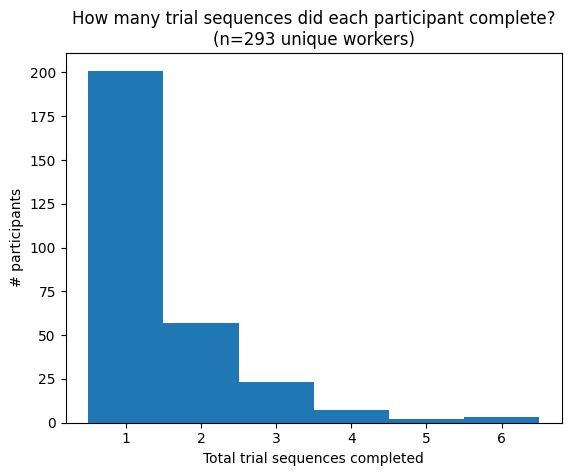

In [5]:
nunique_workers = len(set(df['worker_id']))

number_of_assignments_by_worker = df.groupby('worker_id')['assignment_id'].nunique()

plt.hist(number_of_assignments_by_worker, bins=np.arange(0.5, number_of_assignments_by_worker.max() + 1.5, 1))
plt.xlabel('Total trial sequences completed')
plt.ylabel('# participants')
plt.title(f"How many trial sequences did each participant complete?\n(n={nunique_workers} unique workers)")
plt.show()


## Catch performances

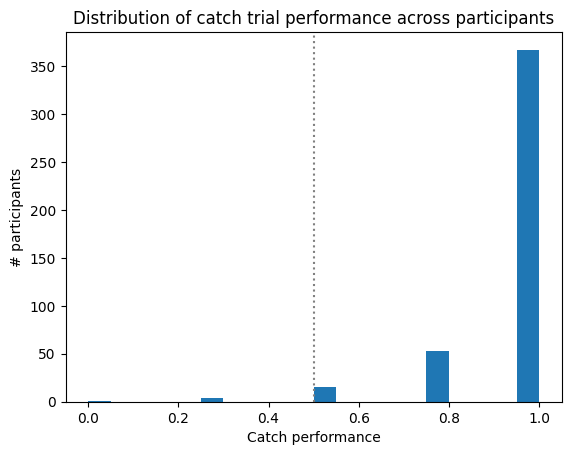

In [6]:
df_catch = df.loc[df['trial_kind'] == 'catch']

catch_performances = df_catch.groupby('assignment_id')['perf'].mean()
plt.hist(catch_performances, bins=20)
plt.axvline(0.5, ls=':', color='gray')
plt.xlabel('Catch performance')
plt.ylabel('# participants')
plt.title("Distribution of catch trial performance across participants")
plt.show()

## Warmup performance

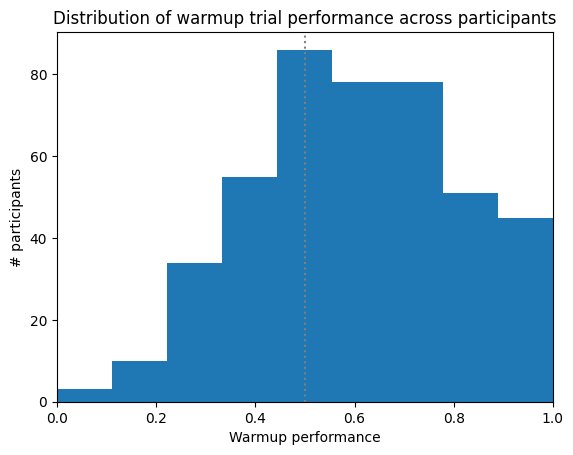

In [7]:
df_warmup = df.loc[df['trial_kind'] == 'warmup']
plt.hist(df_warmup.groupby('assignment_id')['perf'].mean(), bins = np.linspace(0, 1, 10, endpoint=True))
plt.xlim([0, 1])
plt.axvline(0.5, ls=':', color='gray')
plt.xlabel('Warmup performance')
plt.ylabel('# participants')
plt.title("Distribution of warmup trial performance across participants")
plt.show()

## Performance distribution

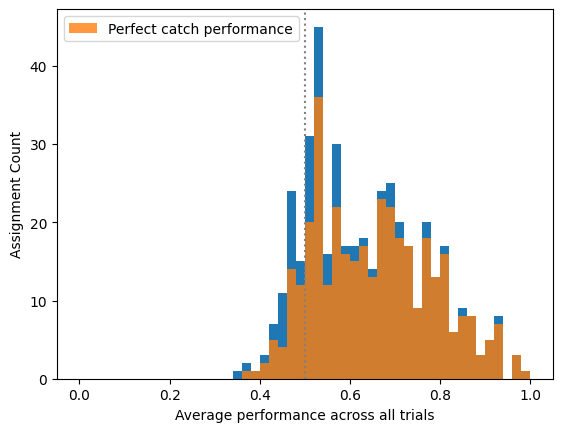

In [8]:
bins = np.linspace(0, 1, 51)
assignment_performances =df.groupby('assignment_id')['perf'].mean()
plt.hist(assignment_performances, bins = bins)
plt.hist(assignment_performances.loc[catch_performances  == 1], bins = bins, alpha=0.8, label='Perfect catch performance')

plt.axvline(0.5, ls=':', color='gray')
plt.xlabel('Average performance across all trials')
plt.ylabel('Assignment Count')
plt.legend()
plt.show()

## Learning curves

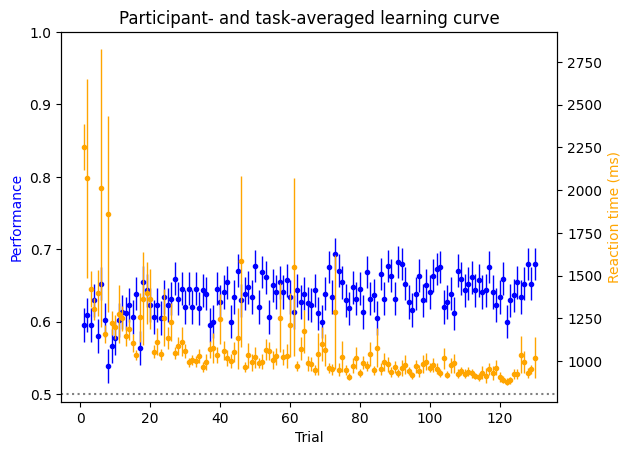

In [9]:
learning_curve = df.groupby('trial')['perf'].mean()
learning_curve_se = df.groupby('trial')['perf'].sem()


rt_curve = df.groupby('trial')['reaction_time_msec'].mean()
rt_curve_se = df.groupby('trial')['reaction_time_msec'].sem()

plt.errorbar(x = 1+np.arange(len(learning_curve)), y=learning_curve, yerr=learning_curve_se, marker = '.', lw=0, elinewidth=1, color='blue')
plt.xlabel('Trial')
plt.ylabel('Performance', color='blue')
plt.axhline(0.5, ls=':', color='gray')
plt.title("Participant- and task-averaged learning curve")
plt.ylim([None, 1])

plt.twinx()
plt.errorbar(x = 1+np.arange(len(rt_curve)), y=rt_curve, yerr=rt_curve_se, marker = '.', lw=0, elinewidth=1, color='orange')
plt.xlabel('Trial')
plt.ylabel('Reaction time (ms)', color='orange')


plt.show()

## Reaction times

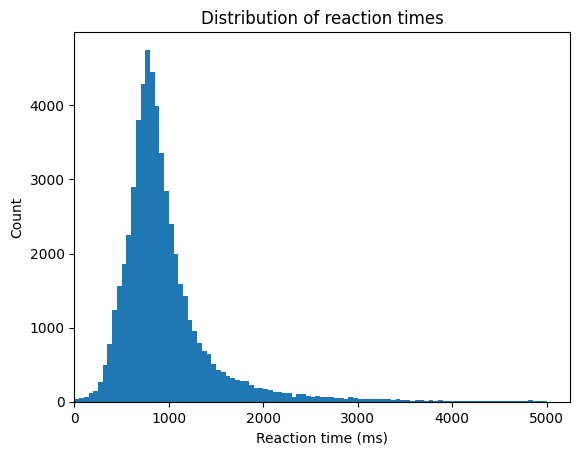

In [10]:
plt.hist(df['reaction_time_msec'], bins=100, range=(0, 5000))
plt.xlabel('Reaction time (ms)')
plt.ylabel('Count')
plt.title("Distribution of reaction times")
plt.xlim([0, None])
plt.show()

# Estimating probe matrices

Below is the 'main' analysis for getting the probe matrix and training data for DLBT etc. It consists of two steps:

1. Assignment filtering, through the use of multiple filtering criteria:
    - a catch performance criterion (participant must have received 4/4)
    - a "main" performance criterion, on the 100 `main` trials. Participant must have received k/100 trials correct, where k is the 95th percentile (or higher) of the binomial distribution with n=100 and p=0.5. This is a lenient criterion that should exclude participants who are not performing above chance on the main trials.
2. Probe matrix estimation: for each probe condition (stimulus, task_id), we compute the mean performance across all observations that pass the filtering criteria. This gives us a 16 x 22 matrix of probe performances.

## Assignment filtering

In [11]:
# Catch performance criterion
catch_performance_by_assignment = df.loc[df['trial_kind'] == 'catch'].groupby('assignment_id')['perf'].mean()
assignments_passing_catch = catch_performance_by_assignment[catch_performance_by_assignment == 1].index
print(f"{len(assignments_passing_catch)} / {len(catch_performance_by_assignment)} assignments passed the catch performance criterion.")

367 / 440 assignments passed the catch performance criterion.


In [12]:
# Main performance criterion
main_performance_by_assignment = df.loc[df['trial_kind'] == 'main'].groupby('assignment_id')['perf'].mean()
main_performance_threshold = np.random.binomial(n=100, p=0.5, size=100000)
main_performance_threshold = np.percentile(main_performance_threshold, 95)
assignments_passing_main = main_performance_by_assignment[main_performance_by_assignment >= main_performance_threshold / 100].index
print(f"{len(assignments_passing_main)} / {len(main_performance_by_assignment)} assignments passed the main performance criterion (threshold: {main_performance_threshold} / 100).")

258 / 440 assignments passed the main performance criterion (threshold: 58.0 / 100).


In [13]:
df_filtered = df.loc[df['assignment_id'].isin(assignments_passing_catch) & df['assignment_id'].isin(assignments_passing_main)]
print(f"{len(df_filtered['assignment_id'].unique())}/{df['assignment_id'].nunique()} unique assignments passed both filtering criteria.")

237/440 unique assignments passed both filtering criteria.


## Probe matrix estimation

In [14]:
df_probe = df_filtered.loc[df_filtered['trial_kind'] == 'probe']

In [15]:
probe_matrix = df_probe.pivot_table('perf', index='stimulus', columns='task_id')
probe_matrix

task_id,glossy,"glossy,large","glossy,large,right","glossy,left","glossy,right",large,"large,left","large,right",left,matte,...,small,transparent,"transparent,glossy","transparent,glossy,large","transparent,glossy,left","transparent,glossy,right","transparent,large","transparent,large,right","transparent,left","transparent,right"
stimulus,,,,,,,,,,,,,,,,,,,,,
000100_shoct_f02_yaw260_s074_lab059--040-+028_t071_gl091_xy-0220--0187_random.png,0.7,0.818182,0.333333,1.0,0.777778,0.923077,0.8,0.6,0.750,1.000000,...,0.909091,0.833333,0.9,0.916667,0.833333,0.888889,0.642857,0.777778,0.750000,0.615385
000237_shoct_f07_yaw261_s043_lab045-+060--055_t010_gl040_xy-0119--0164_random.png,0.9,0.818182,0.833333,1.0,0.666667,1.000000,0.4,0.8,0.875,0.833333,...,1.000000,0.944444,0.8,1.000000,0.833333,1.000000,0.857143,1.000000,0.666667,1.000000
000321_shoct_f04_yaw097_s073_lab046--044-+025_t067_gl019_xy-0220--0125_random.png,0.1,0.000000,0.416667,0.0,0.777778,0.692308,1.0,0.7,0.875,0.500000,...,1.000000,0.722222,0.7,0.416667,0.750000,0.777778,0.642857,0.666667,0.750000,0.692308
000443_shdod_f00_yaw153_s048_lab062-+066-+003_t092_gl038_xy-0067--0204_random.png,0.1,0.454545,0.500000,0.5,0.888889,0.769231,0.5,0.7,0.875,0.166667,...,0.818182,0.944444,0.3,0.500000,0.250000,0.722222,0.642857,0.666667,0.583333,0.461538
000477_shoct_f02_yaw254_s079_lab072--026--031_t050_gl054_xy+0141-+0183_random.png,0.8,0.909091,0.833333,0.5,0.888889,0.923077,0.7,1.0,1.000,1.000000,...,0.727273,0.000000,0.3,0.166667,0.500000,0.222222,0.142857,0.000000,0.666667,0.076923
000517_shdod_f08_yaw086_s080_lab047-+073-+022_t009_gl086_xy-0029--0176_random.png,0.5,0.909091,0.666667,1.0,0.888889,1.000000,0.9,0.3,1.000,0.500000,...,0.909091,0.555556,0.8,0.250000,0.833333,0.722222,0.500000,0.555556,0.583333,0.769231
000613_shdod_f04_yaw120_s063_lab065--016--038_t036_gl068_xy-0192--0247_random.png,0.8,0.181818,0.583333,1.0,0.777778,0.153846,0.3,0.7,0.875,1.000000,...,0.000000,0.055556,0.1,0.416667,0.500000,0.722222,0.500000,0.888889,0.250000,0.692308
000624_shico_f10_yaw196_s048_lab052-+012-+038_t010_gl086_xy+0066--0075_random.png,0.6,0.818182,0.666667,1.0,0.777778,0.923077,0.9,0.8,0.875,0.666667,...,1.000000,0.500000,0.7,0.750000,1.000000,0.611111,0.642857,0.666667,0.666667,0.846154
000722_shoct_f04_yaw313_s085_lab070--028-+061_t071_gl037_xy+0079--0004_random.png,0.1,0.181818,0.166667,0.5,0.111111,1.000000,0.6,1.0,0.875,0.166667,...,0.727273,0.888889,0.4,0.333333,0.416667,0.277778,0.857143,0.888889,0.583333,0.923077


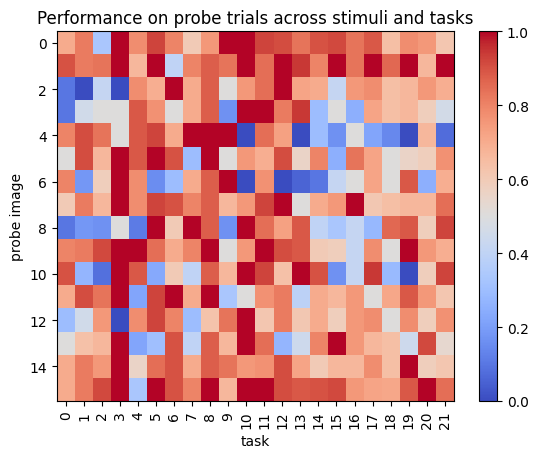

In [293]:
plt.imshow(
    probe_matrix,
    vmin=0, vmax =1, cmap='coolwarm',
    aspect='auto'
)
plt.xlabel('task')
plt.ylabel('probe image')
plt.xticks(range(probe_matrix.shape[1]), rotation=90)
plt.colorbar()

plt.title("Performance on probe trials across stimuli and tasks")
plt.show()

## Estimating the split-half reliability of the probe matrix

Here, a probe condition is defined by the tuple `(stimulus, task_id)`. For each probe condition, we split all observations into two halves by random assignment of `assignment_id` to one of the halves. Then we compute the mean performance in each half, and compute the Pearson correlation coefficient across probe conditions between the two halves. We repeat this process over 100 splits, and report the mean and standard deviation over splits. This gives us an estimate of the reliability of the probe condition performances.

Note that a given participant might show up in both halves; we are splitting by _assignment_id_, not by _worker_id_. This would happen when one participant performed multiple sequences for a single task.

In [16]:
# Check that each task has at least two unique assignments that pass the filtering criteria, so that we can do the split-half reliability analysis
for task_id, df_task in df_filtered.groupby('task_id'):
    assert (df_task['assignment_id'].nunique()) >=2

In [17]:
num_splits = 100
reliabilities = []
for seed in tqdm(range(num_splits)):
    gen = np.random.default_rng(seed)
    half1_assignment_ids = []
    half2_assignment_ids = []


    for task_id, df_task in df_filtered.groupby('task_id'):
        # Randomly split assignments into two halves
        assignment_ids = list(df_task['assignment_id'].unique())
        gen.shuffle(assignment_ids)

        # Check if odd number:
        is_odd = len(assignment_ids) % 2 == 1

        # If odd, with 50-50 chance assign the extra assignment to either half:
        n_half1 = len(assignment_ids) // 2
        if is_odd and gen.random() < 0.5:
            n_half1 = len(assignment_ids) // 2 + 1

        half1_assignment_ids.extend(assignment_ids[:n_half1])
        half2_assignment_ids.extend(assignment_ids[n_half1:])



    df_half1 = df_filtered.loc[df_filtered['assignment_id'].isin(half1_assignment_ids) & (df_filtered['trial_kind'] == 'probe')]
    df_half2 = df_filtered.loc[df_filtered['assignment_id'].isin(half2_assignment_ids) & (df_filtered['trial_kind'] == 'probe')]

    probe_matrix_half1 = df_half1.pivot_table('perf', index='stimulus', columns='task_id')
    probe_matrix_half2 = df_half2.pivot_table('perf', index='stimulus', columns='task_id')
    split_half_reliability = ss.pearsonr(probe_matrix_half1.values.flatten(), probe_matrix_half2.values.flatten())[0]

    reliabilities.append(split_half_reliability)




100%|██████████| 100/100 [00:01<00:00, 61.76it/s]


In [18]:
print(f'Split-half reliability estimate of probe matrix: {np.mean(reliabilities):.2f}+-{np.std(reliabilities, ddof=1):.2f}', )

Split-half reliability estimate of probe matrix: 0.60+-0.03
